In [2]:
import os
import sys
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import metpy.constants as mpconst
import numpy as np
import xarray as xr

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    sys.path.insert(1, "../onset_identification")
from mse import (
    calc_meridional_energy_flux,
    calculate_mse,
    mass_weighted_column_integral,
)
from utils import (
    domains,
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    ifs_hp_mods,
    relon,
    sim_colors,
    sim_labels,
    sim_specific_labels,
    sims,
    sims_new,
    um_sims,
)

print("yes")

imports done
yes


## era5 test

In [5]:
era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
full_era5 = xr.open_zarr(era5_path, chunks="auto", storage_options=dict(token="anon"))
era5_dyperiod = full_era5.sel(time=slice("2020-03-01", "2020-03-02")).rename(
    {"level": "pressure"}
)[
    [
        "v_component_of_wind",
        "temperature",
        "specific_humidity",
        "geopotential",
        "surface_pressure",
    ]
]

In [ ]:
va = era5_dyperiod.v_component_of_wind
ta = era5_dyperiod.temperature
hus = era5_dyperiod.specific_humidity
zg = era5_dyperiod.geopotential
ps = era5_dyperiod.surface_pressure

In [ ]:
h = calculate_mse(ta, zg, hus)
dse = zg + mpconst.dry_air_spec_heat_press.magnitude * ta
DSE = mass_weighted_column_integral(h, ps)
H = mass_weighted_column_integral(h, ps)
vH = mass_weighted_column_integral(va * h)
# monthly_energy_flux = calc_meridional_energy_flux(vH).resample(time="1ME").mean()

In [ ]:
DSE.mean(dim=("longitude","time")).plot(label="Column-integrated DSE")
H.mean(dim=("longitude","time")).plot(label="Column-integrated MSE")
plt.legend()

In [ ]:
plot = monthly_energy_flux.plot(col="time", col_wrap=4,)
plot.map(lambda: plt.grid(True))

## now these godawful simulations

In [2]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3
sim = um_sims[0]
sim_cat = cat[sim]
ds3d = hp_to_latlon(sim_cat(zoom=zoom, time="PT3H").to_dask().pipe(hp_mods),zoom)
ps = hp_to_latlon(sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods).ps,zoom)

In [3]:
ds3d.zg

<xarray.DataArray 'zg' (time: 3249, pressure: 25, latitude: 25, longitude: 49)> Size: 398MB
dask.array<transpose, shape=(3249, 25, 25, 49), dtype=float32, chunksize=(1024, 5, 15, 49), chunktype=numpy.ndarray>
Coordinates:
  * pressure   (pressure) int64 200B 1 5 10 20 30 50 ... 900 925 950 975 1000
  * time       (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
    crs        int64 8B 0
    cell       (latitude, longitude) int64 10kB 512 512 512 512 ... 255 255 63
    lat        (latitude, longitude) float64 10kB -84.15 -84.15 ... 84.15 84.15
    lon        (latitude, longitude) float64 10kB 45.0 45.0 45.0 ... 315.0 45.0
  * latitude   (latitude) float64 200B -90.0 -82.5 -75.0 ... 75.0 82.5 90.0
  * longitude  (longitude) float64 392B 0.0 7.5 15.0 22.5 ... 345.0 352.5 360.0
Attributes:
    standard_name:  geopotential_height
    units:          m
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 16, 202]
    long_name:      geopotential_height
    variable_id:    zg
    UM_vars:        ['geopotential_height']
    grid_mapping:   crs

In [28]:
dse = (
    ds3d.zg + mpconst.dry_air_spec_heat_press.magnitude * ds3d.ta
)
DSE = mass_weighted_column_integral(dse, ps)
mse = dse + mpconst.water_heat_vaporization.magnitude * ds3d.hus
MSE = mass_weighted_column_integral(mse, ps)
vH = mass_weighted_column_integral(ds3d.va * mse, ps)
V = mass_weighted_column_integral(ds3d.va, ps)

/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/dask/array/core.py:4988: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/dask/array/core.py:4988: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/dask/array/core.py:4988: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/dask/array/core.py:4988: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


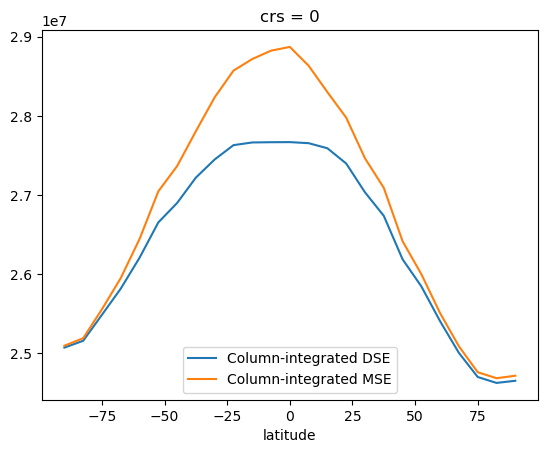

In [29]:
DSE.mean(dim=("longitude","time")).plot(label="Column-integrated DSE")
MSE.mean(dim=("longitude","time")).plot(label="Column-integrated MSE")
plt.legend()

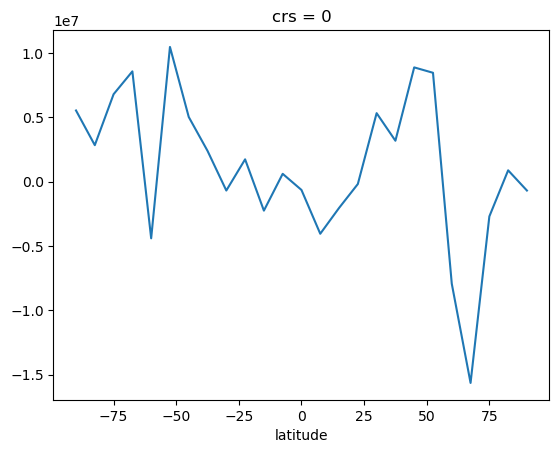

In [30]:
vH.mean(dim=("longitude","time")).plot(label="Column-integrated MMF")
# V.mean(dim=("longitude","time")).plot(label="Column-integrated v-wind")


In [31]:

    R_e = mpconst.earth_avg_radius.magnitude
    vH_rad = vH.assign_coords({"longitude": np.deg2rad(vH["longitude"])})
    vH_int = vH_rad.integrate(coord="longitude")
    f_total = vH_int * R_e * np.cos(np.deg2rad(vH["latitude"]))



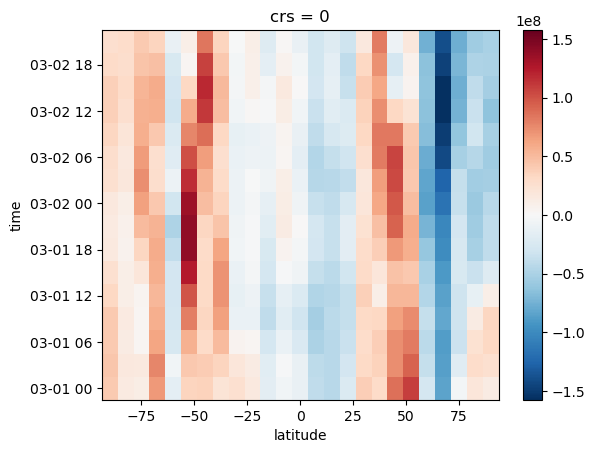

In [38]:
vH_int.plot()

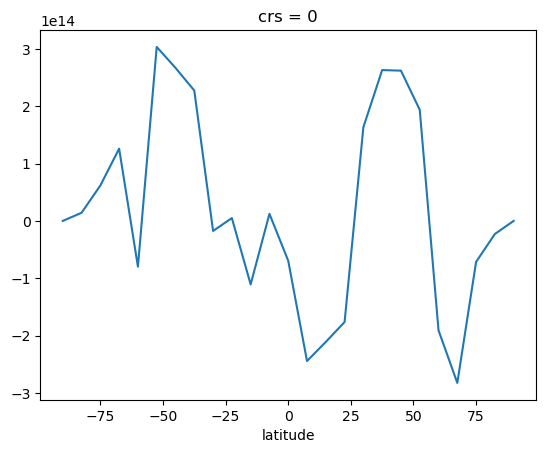

In [34]:
f_total.mean(dim=("time")).plot(label="Column-integrated MMF")


In [3]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3

for sim in sims[2:]:
    sim_cat = cat[sim]
    print(sim)
    
    if "hk26" in sim:
        ds = sim_cat(zoom=zoom, time="PT3H").to_dask().pipe(hp_mods)
    else:
        if "icon" in sim:
            ds = (
                sim_cat(zoom=zoom, time="P1D", time_method="mean")
                .to_dask()
                .pipe(egh.attach_coords)
            )
        elif "nicam" in sim or "cas" in sim:
            ds = sim_cat(zoom=zoom, time="PT6H").to_dask().pipe(egh.attach_coords)
        elif "ifs" in sim:
            zoom = 7
            ds = sim_cat(zoom=zoom,dim="3D").to_dask().pipe(ifs_hp_mods)
            ds=ds.rename({"u":"ua","v":"va","q":"hus","t":"ta","z":"zg"})
        else:
            ds = sim_cat(zoom=zoom,).to_dask().pipe(egh.attach_coords)
    ds = hp_to_latlon(ds.sel(time=slice("2020-03-01", "2021-02-28")), zoom)
    if max(ds.longitude) > 180:
        ds = relon(ds).sortby("longitude")
    
    h = calculate_mse(ds.ta, ds.zg, ds.hus)
    H = mass_weighted_column_integral(h,ds.ps)
    vH = mass_weighted_column_integral(ds.va * h)
    monthly_energy_flux = (
        calc_meridional_energy_flux(vH)
        .resample(time="1ME")
        .mean()
    )
    plot = monthly_energy_flux.plot(col="time", col_wrap=4,)
    plot.map(lambda: plt.grid(True))
    plt.suptitle(sim)
    plt.savefig(f"{sim}.png")

casesm2_10km_nocumulus


In [ ]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3

for sim in sims:
    sim_cat = cat[sim]
    
    if "hk26" in sim:
        ds = sim_cat(zoom=zoom, time="PT3H").to_dask().pipe(hp_mods)
    else:
        if "icon" in sim:
            ds = (
                sim_cat(zoom=zoom, time="P1D", time_method="mean")
                .to_dask()
                .pipe(egh.attach_coords)
            )
        elif "nicam" in sim:
            ds = sim_cat(zoom=zoom, time="PT6H").to_dask().pipe(egh.attach_coords)
        elif "ifs" in sim:
            zoom = 7
            ds = sim_cat(zoom=7,dim="3D").to_dask().pipe(ifs_hp_mods)
            ds=ds.rename({"u":"ua","v":"va","q":"hus","t":"ta","z":"zg"})
        else:
            ds = sim_cat(zoom=zoom,).to_dask().pipe(egh.attach_coords)
    ds = hp_to_latlon(ds, zoom)
    if max(ds.longitude) > 180:
        ds = relon(ds).sortby("longitude")
    
    h = calculate_mse(ds.ta, ds.zg, ds.hus)
    H = mass_weighted_column_integral(h).resample(time="1ME").mean()
    vH = mass_weighted_column_integral(ds.va.resample(time="1ME").mean() * h)
    monthly_energy_flux = (
        calc_meridional_energy_flux(vH)
        .sel(time=slice("2020-03-01", "2021-02-28"))
    )
    monthly_energy_flux.plot(col="time", col_wrap=4,grid=True)
    plt.suptitle(sim)
    plt.savefig(f"{sim}.png")

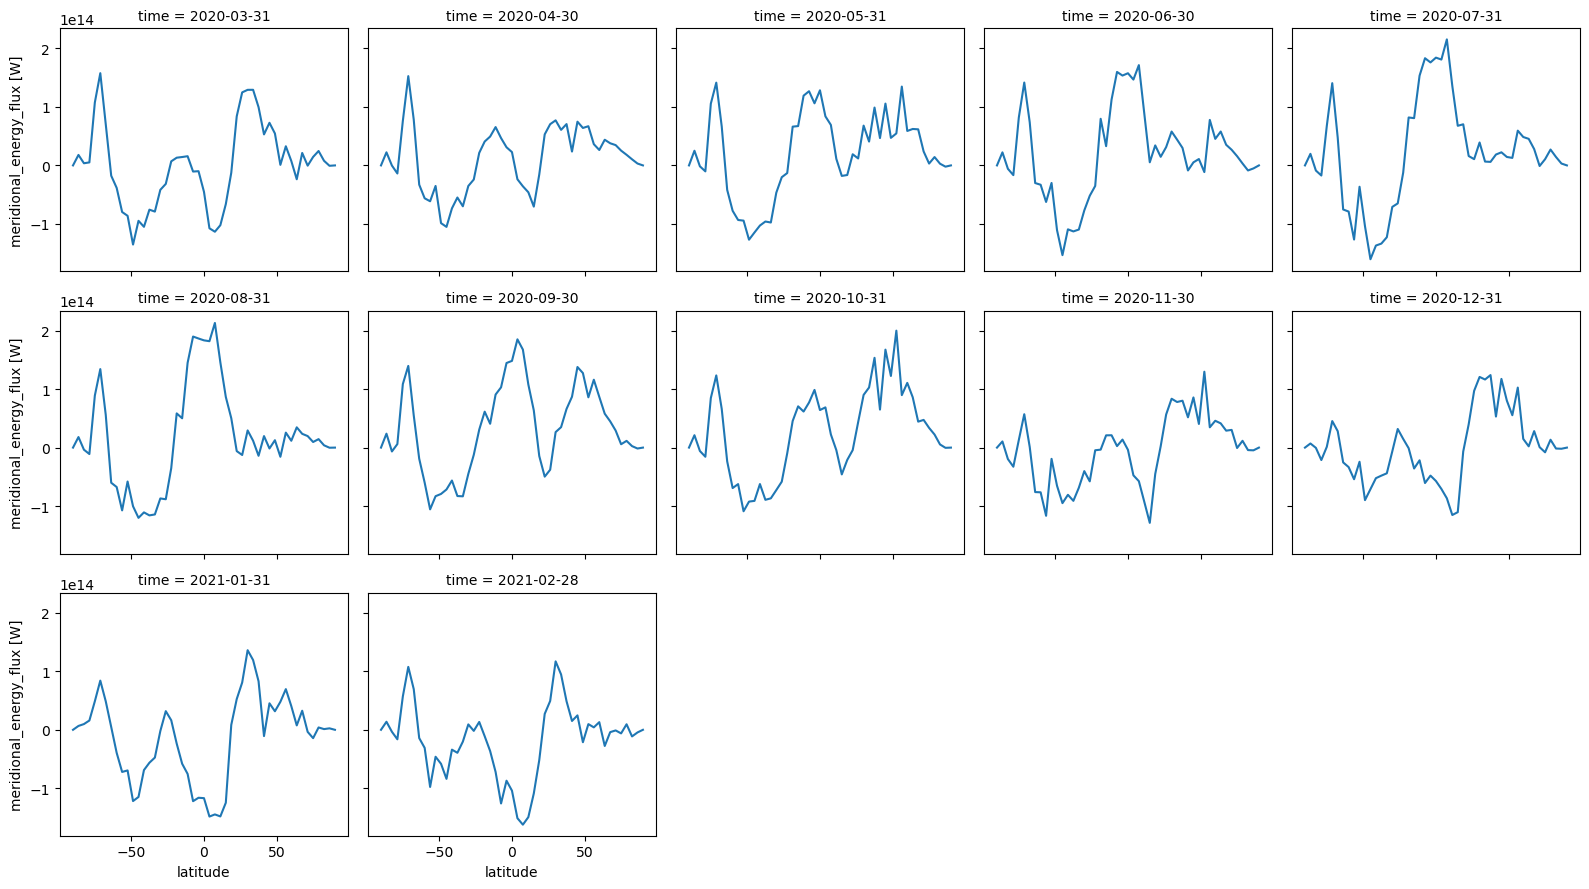

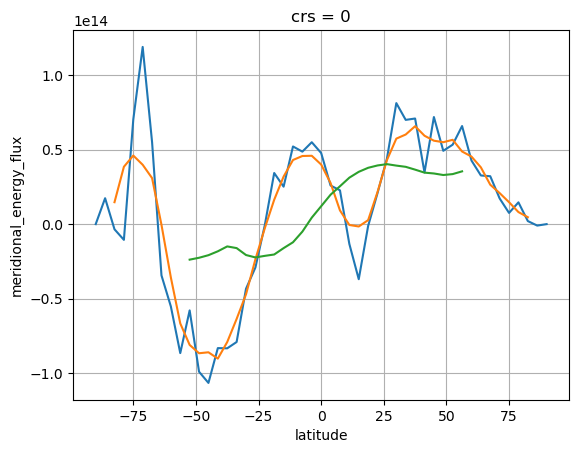

In [65]:
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).plot()
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).rolling(latitude=5,center=True).mean().plot()
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).rolling(latitude=20,center=True).mean().plot()
plt.grid()

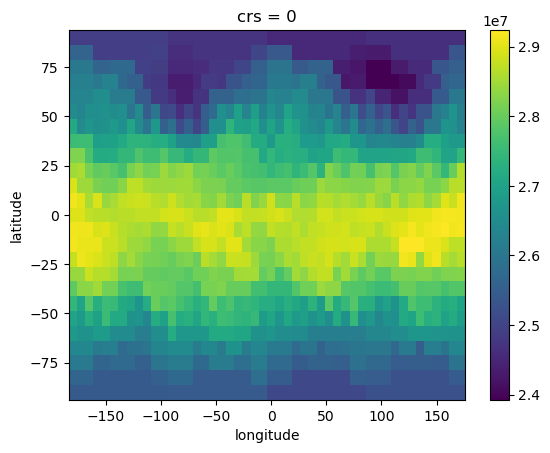

In [34]:
H.sel(time="2020-02-25").mean(dim="time").plot()

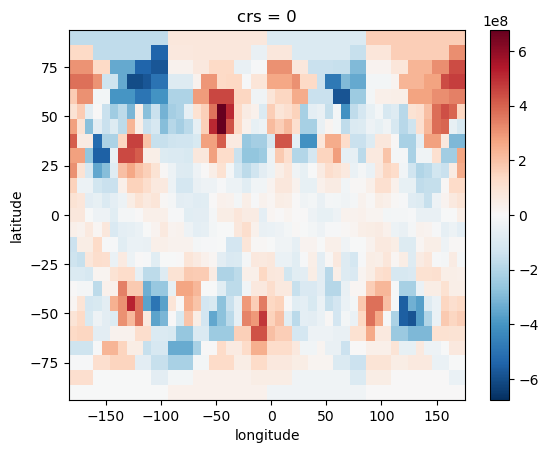

In [12]:
vH.sel(time="2020-02-25").mean(dim="time").plot()


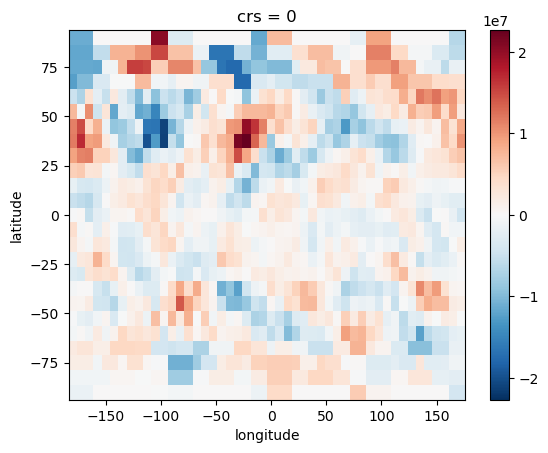

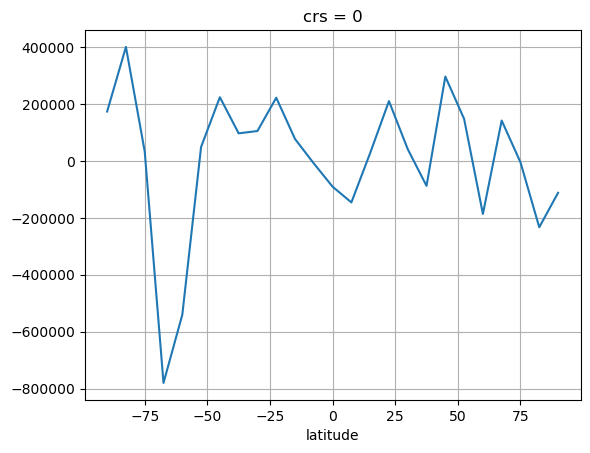

# Visualising existing files

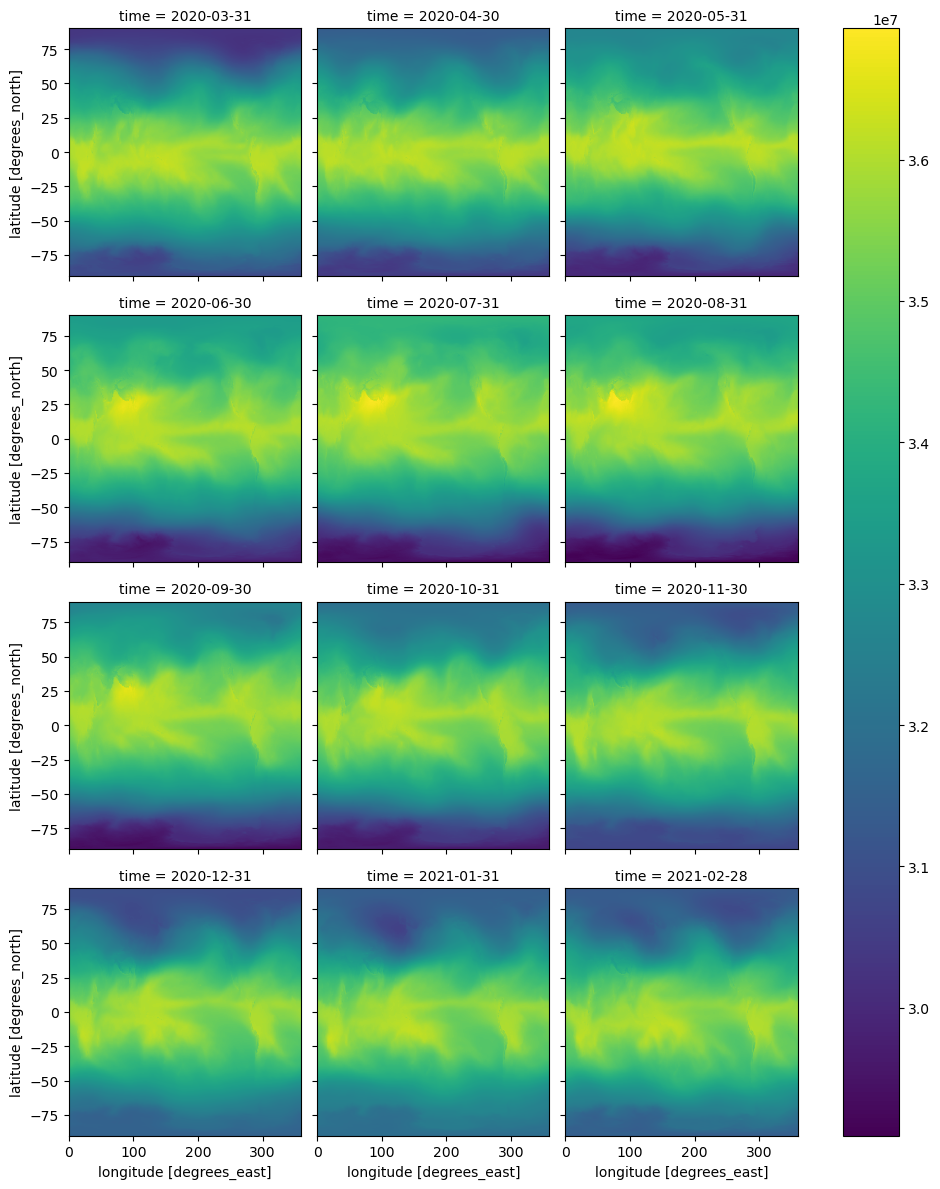

In [9]:
xr.open_dataarray("monthly_era5_MSE.nc").plot(col="time",col_wrap=3)

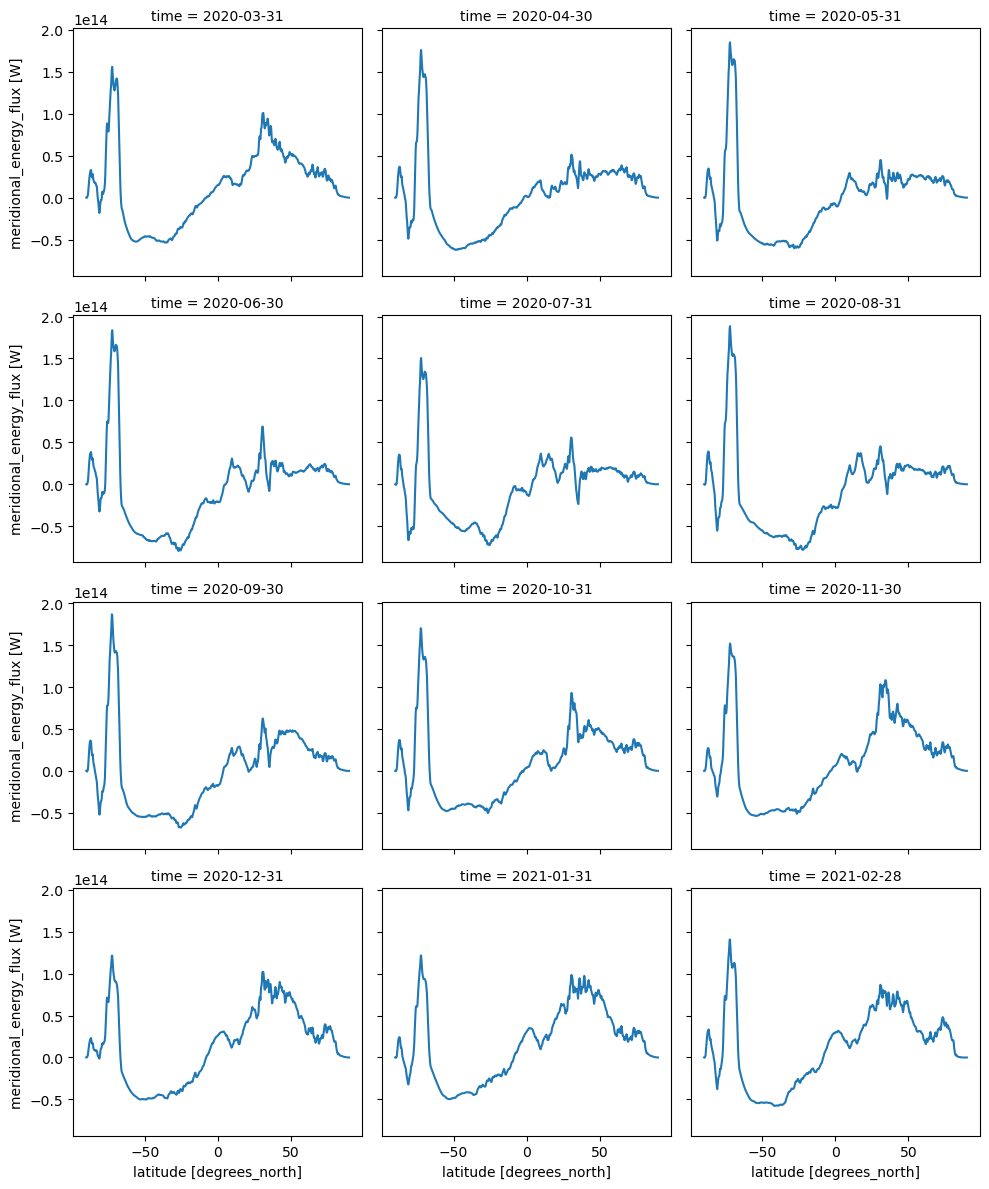

In [10]:
xr.open_dataarray("monthly_era5_MEF.nc").plot(col="time",col_wrap=3)


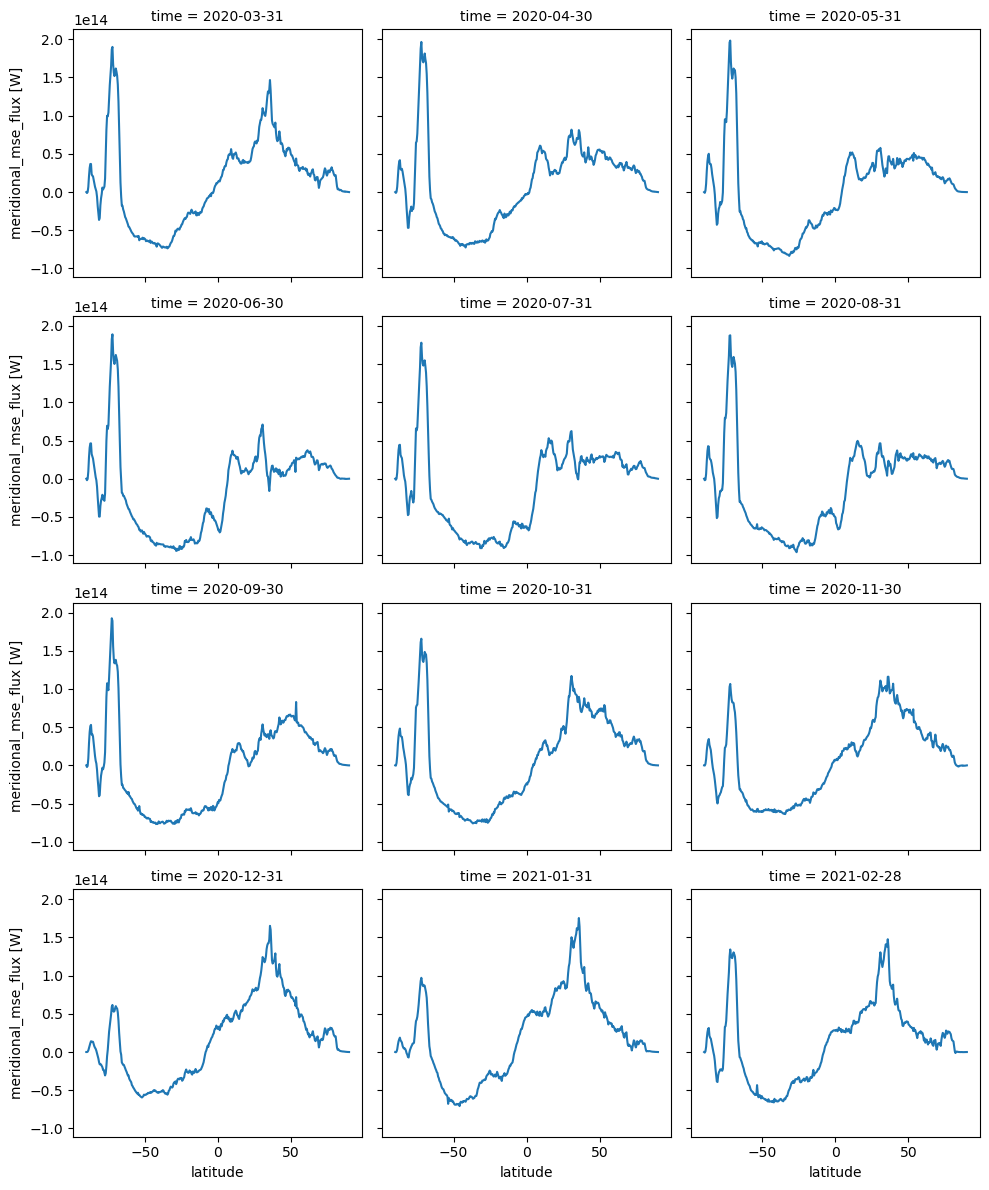

In [17]:
xr.open_dataarray("monthly_um_glm_n2560_RAL3p3_tuned_hk26_MEF_zoom_7.nc").plot(
    col="time", col_wrap=3
)

In [18]:
xr.open_dataarray("monthly_um_glm_n2560_RAL3p3_tuned_hk26_MEF_zoom_7.nc").time

<xarray.DataArray 'time' (time: 12)> Size: 96B
array(['2020-03-31T00:00:00.000000000', '2020-04-30T00:00:00.000000000',
       '2020-05-31T00:00:00.000000000', '2020-06-30T00:00:00.000000000',
       '2020-07-31T00:00:00.000000000', '2020-08-31T00:00:00.000000000',
       '2020-09-30T00:00:00.000000000', '2020-10-31T00:00:00.000000000',
       '2020-11-30T00:00:00.000000000', '2020-12-31T00:00:00.000000000',
       '2021-01-31T00:00:00.000000000', '2021-02-28T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
  * time     (time) datetime64[ns] 96B 2020-03-31 2020-04-30 ... 2021-02-28
Attributes:
    standard_name:  time

In [13]:
xr.date_range(start="2020-03",end="2021-02",freq="1ME")

DatetimeIndex(['2020-03-31', '2020-04-30', '2020-05-31', '2020-06-30',
               '2020-07-31', '2020-08-31', '2020-09-30', '2020-10-31',
               '2020-11-30', '2020-12-31', '2021-01-31'],
              dtype='datetime64[ns]', freq='ME')

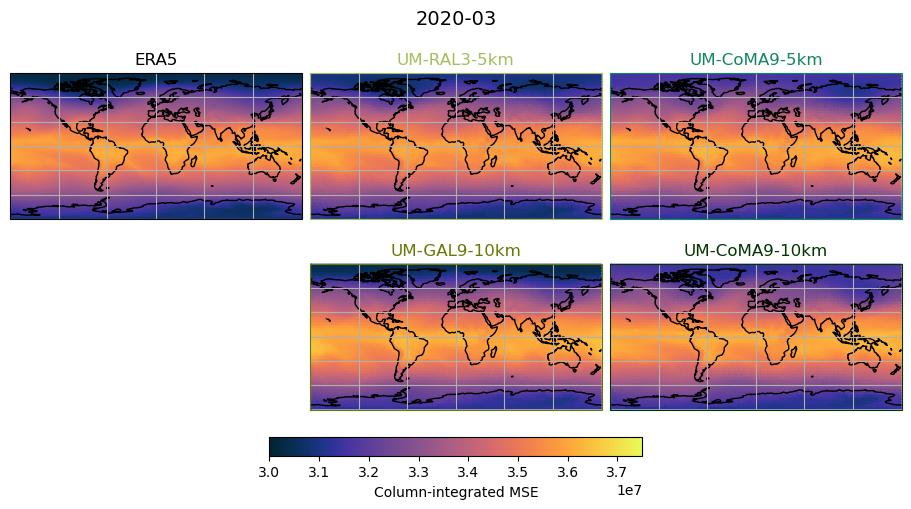

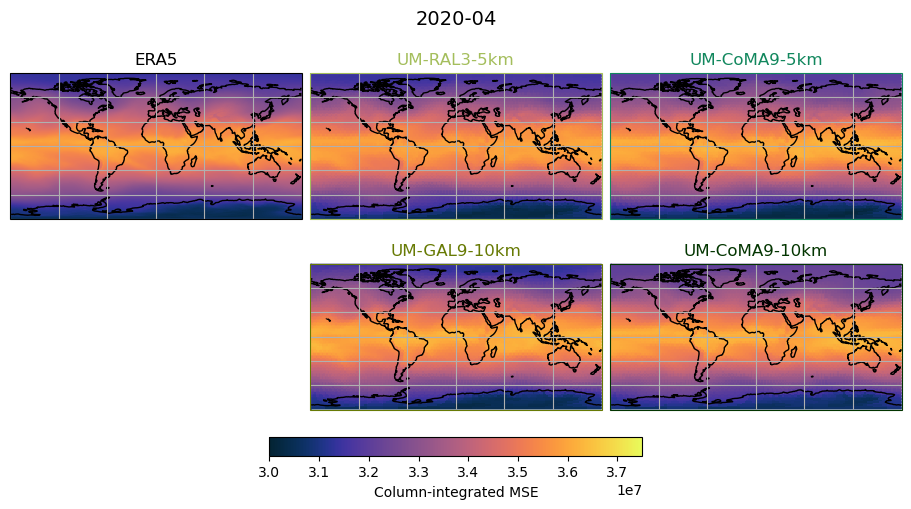

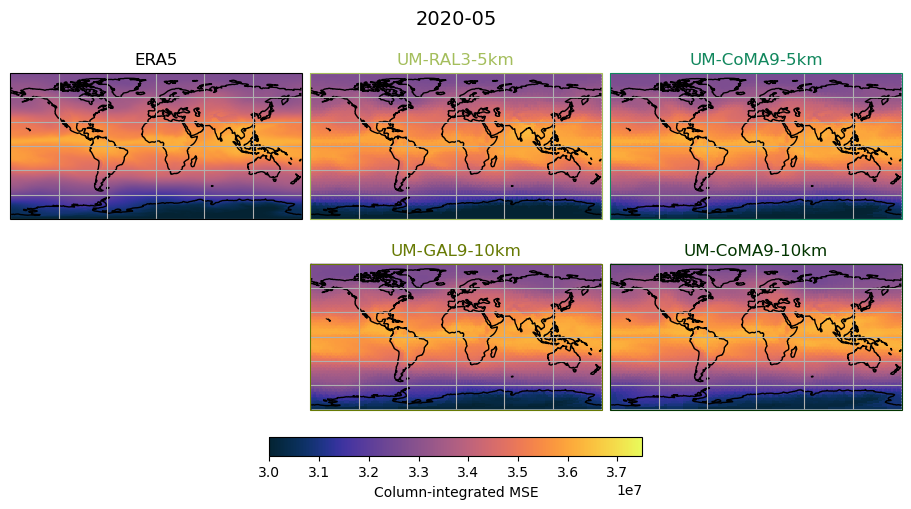

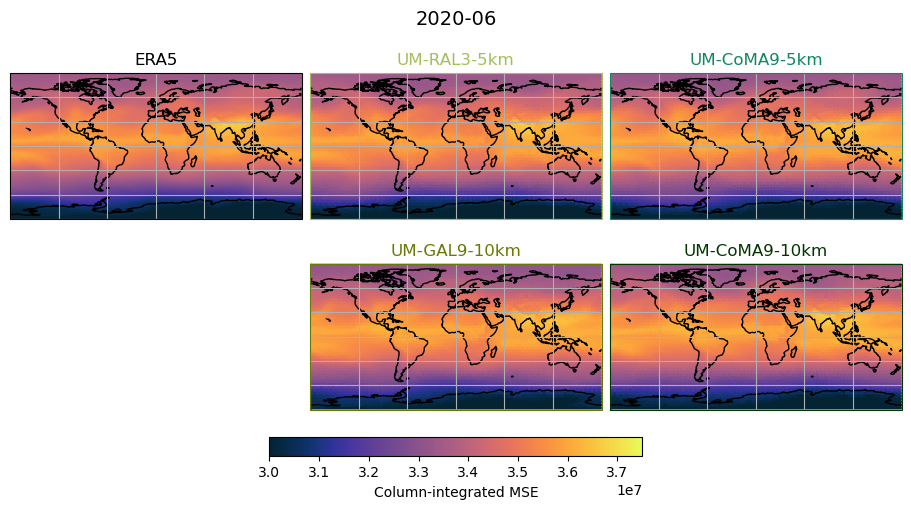

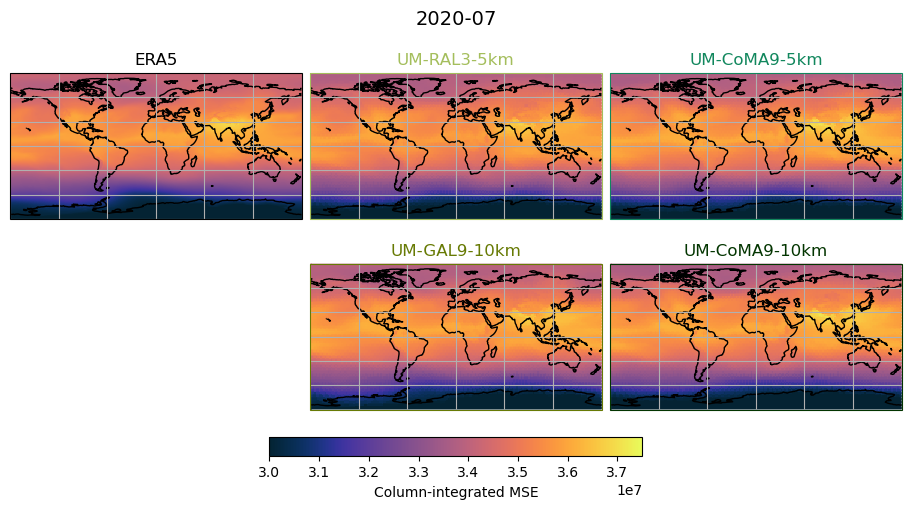

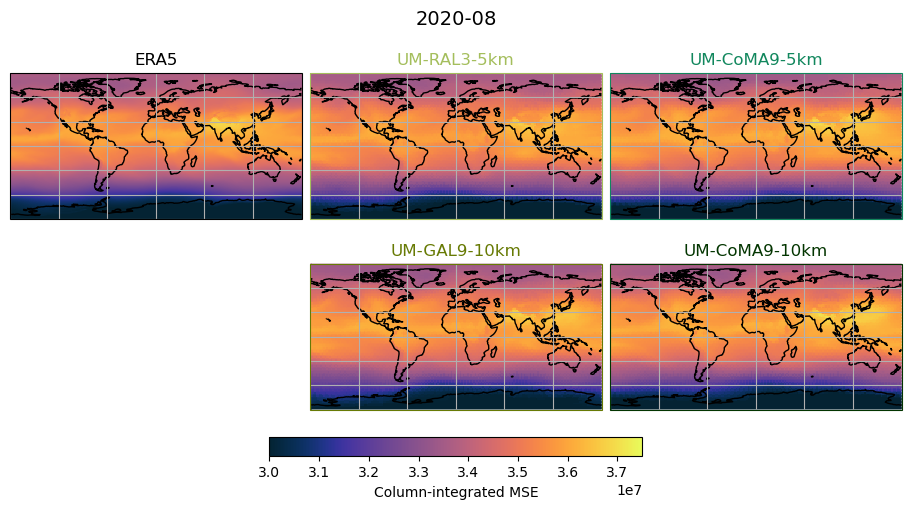

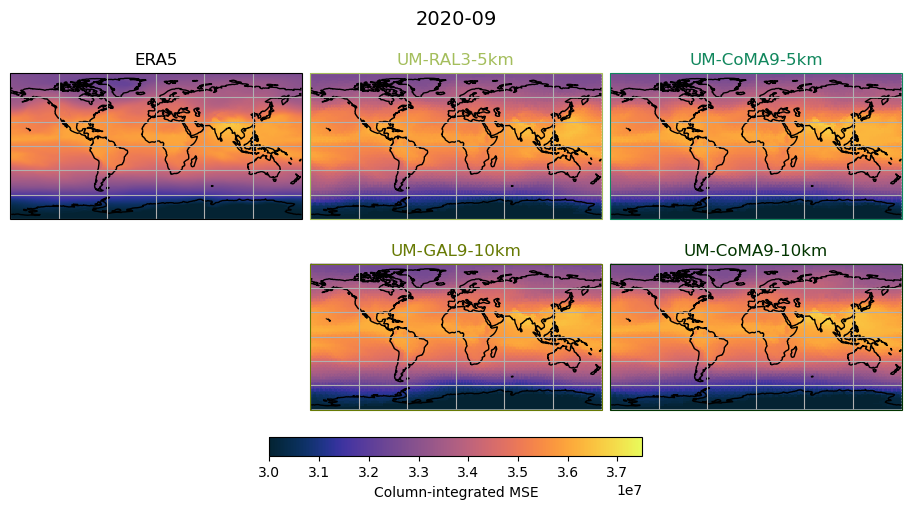

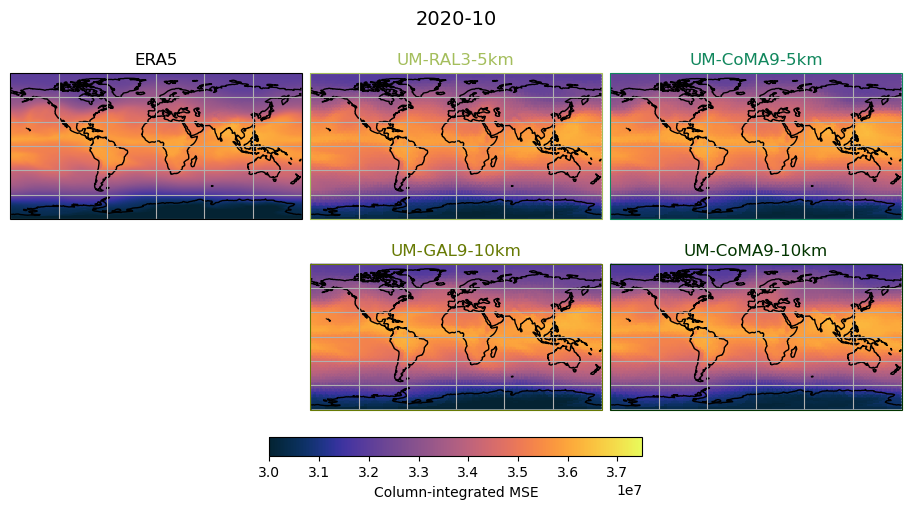

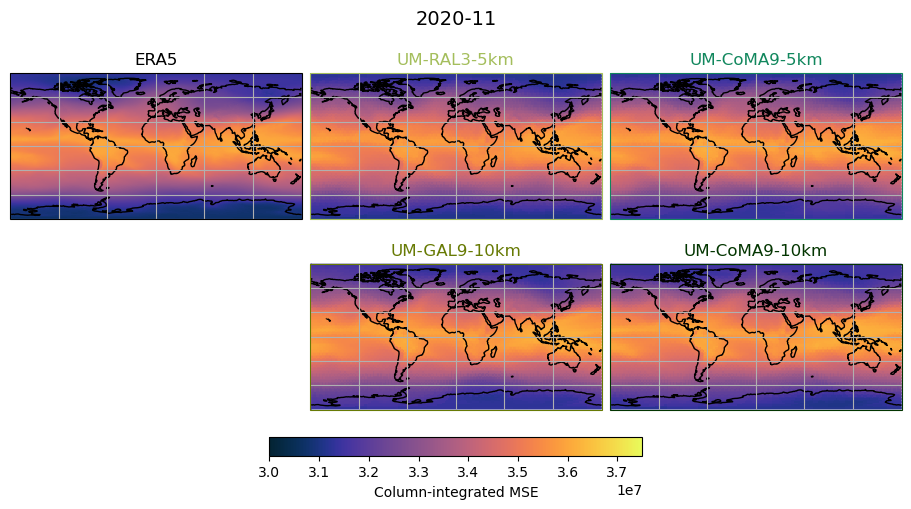

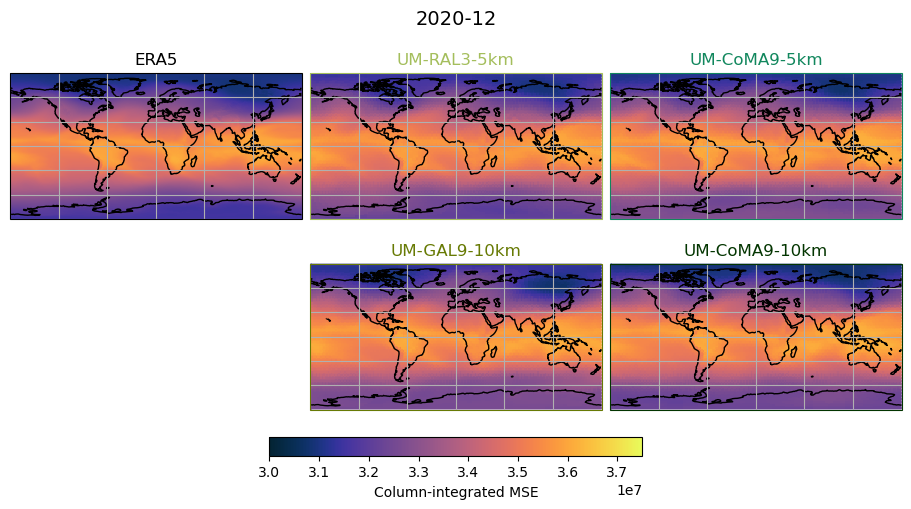

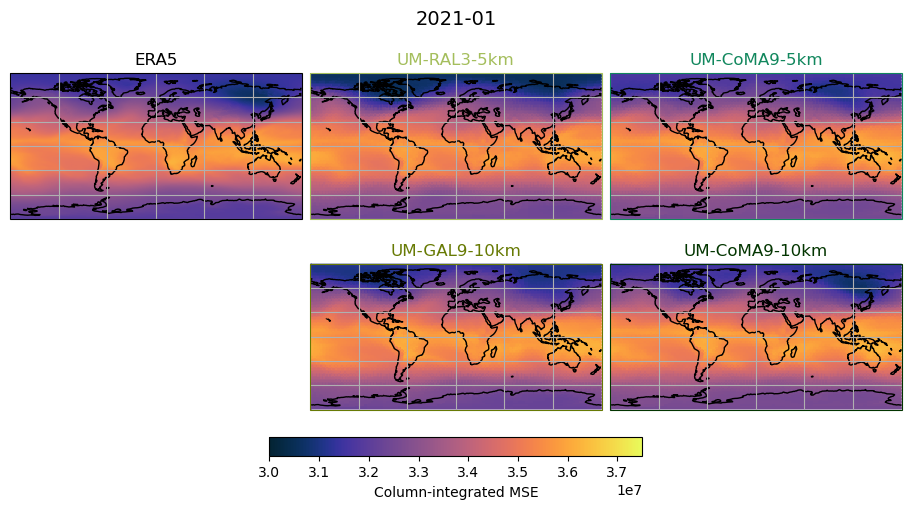

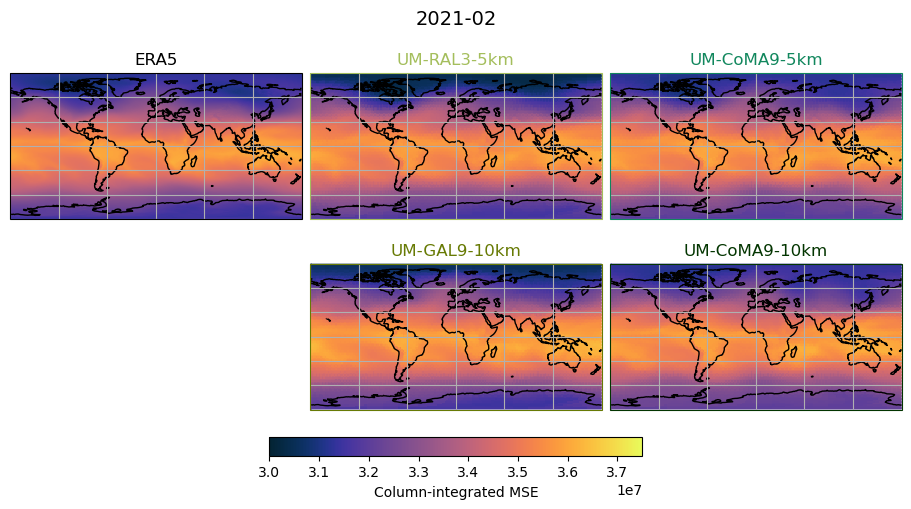

In [44]:
def plot_mse(
    ax,
    sim,
    extent=None,
    zoom=7,
    period_ix=0,
    thresholds="",
    color="k",
    title=None,
    month=None,
):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    if title == None:
        title = sim
    if sim.lower() == "era5":
        da = xr.open_dataarray(f"monthly_era5_MSE.nc")

    else:
        da = xr.open_dataarray(f"monthly_{sim}_MSE_zoom_{zoom}.nc")

    da = da.sel(time=month,method="nearest")

    m = da.plot(cmap=cmo.cm.thermal, vmin=3e7,vmax=3.75e7, ax=ax, add_colorbar=False)

    ax.coastlines()
    ax.gridlines()
    ax.set_title(title, color=color)
    ax.tick_params(color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
    return ax, m

figsize = (9, 5)

for month_ix,month in enumerate(xr.open_dataarray("monthly_era5_MSE.nc").time):
    projection = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        2,
        3,
        # height_ratios=[1] * len(zooms) + [0.1],
        figsize=figsize,
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    
    ax, m = plot_mse(
        axes[0, 0], "ERA5", month=month
    )

    
    for sim_ix, sim in enumerate(um_sims):
        ax, m = plot_mse(
            axes.transpose().flatten()[sim_ix+2],
            sim,
            color=sim_colors[sim],
            title=sim_specific_labels[sim],
            month=month,
            zoom=5
        )
    
    
    fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="Column-integrated MSE",
    )
    axes[1, 0].set_frame_on(False)
    # axes[1, 3].set_frame_on(False)
    fig.suptitle(str(month.dt.strftime("%Y-%m").data),size=14)
    plt.savefig(f"mean_plots_um/mean_plots_um_{str(month_ix).zfill(2)}.png")

FileNotFoundError: [Errno 2] No such file or directory: '/home/users/franmorr/hk26/hackathon-monsoons/mse/monthly_nicam_gl11_MSE_zoom_5.nc'

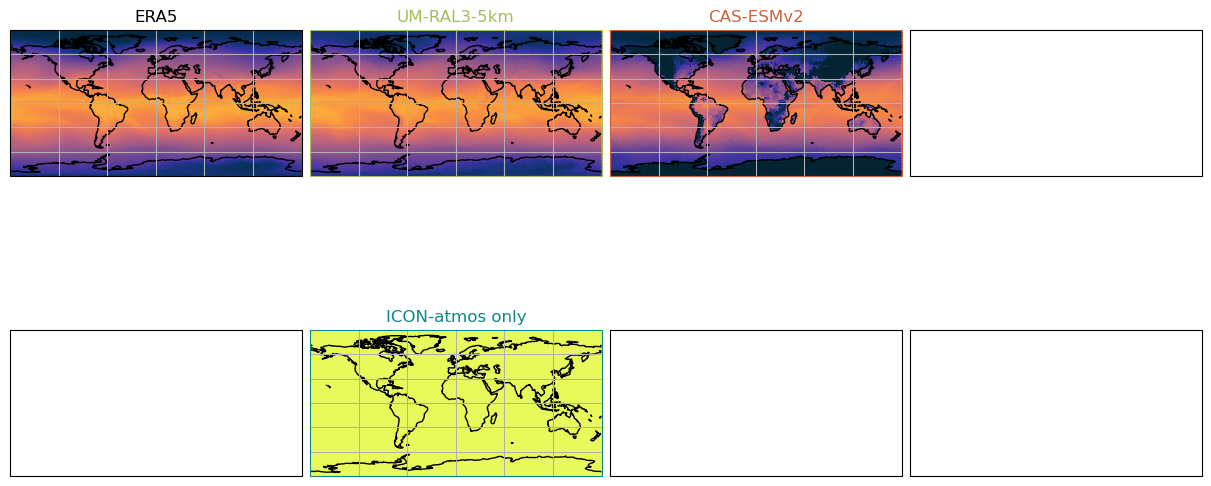

In [3]:
def plot_mse(
    ax,
    sim,
    extent=None,
    zoom=7,
    period_ix=0,
    thresholds="",
    color="k",
    title=None,
    month=None,
):
    if extent:
        ax.set_extent(extent)
    else:
        ax.set_global()
    if title == None:
        title = sim
    if sim.lower() == "era5":
        da = xr.open_dataarray(f"monthly_era5_MSE.nc")

    else:
        da = xr.open_dataarray(f"monthly_{sim}_MSE_zoom_{zoom}.nc")

    da = da.sel(time=month,method="nearest")

    m = da.plot(cmap=cmo.cm.thermal, vmin=3e7,vmax=3.75e7, ax=ax, add_colorbar=False)

    ax.coastlines()
    ax.gridlines()
    ax.set_title(title, color=color)
    ax.tick_params(color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
    return ax, m

figsize = (12, 6)

for month_ix,month in enumerate(xr.open_dataarray("monthly_era5_MSE.nc").time):
    projection = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        2,
        4,
        # height_ratios=[1] * len(zooms) + [0.1],
        figsize=figsize,
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    
    ax, m = plot_mse(
        axes[0, 0], "ERA5", month=month
    )

    
    for sim_ix, sim in enumerate(sims_new):
        ax, m = plot_mse(
            axes.transpose().flatten()[sim_ix+2],
            sim,
            color=sim_colors[sim],
            title=sim_specific_labels[sim],
            month=month,
            zoom=5
        )
    
    
    fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="Column-integrated MSE",
    )
    axes[1, 0].set_frame_on(False)
    axes[1, 3].set_frame_on(False)
    fig.suptitle(str(month.dt.strftime("%Y-%m").data),size=14)
    plt.savefig(f"mean_plots_all/{str(month_ix).zfill(2)}.png")

Text(0, 0.5, 'Meridional column-integrated MSE flux')

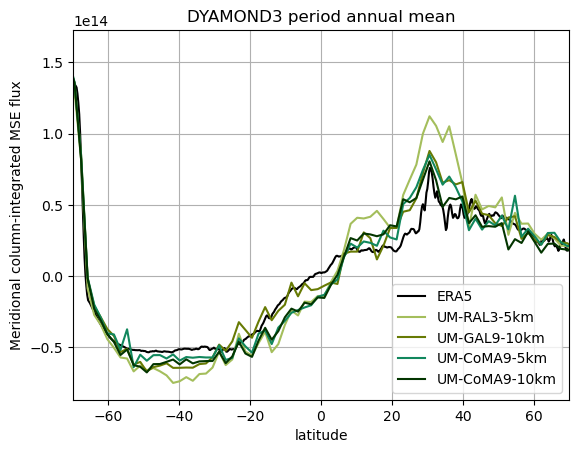

In [32]:
xr.open_dataarray("monthly_era5_MEF.nc").mean(dim="time").plot(
    label="ERA5", color="black"
)

for sim in um_sims:
    xr.open_dataarray(f"monthly_{sim}_MEF_zoom_5.nc").mean(dim="time").plot(
        label=sim_specific_labels[sim], color=sim_colors[sim]
    )
plt.legend()
plt.grid()
plt.title("DYAMOND3 period annual mean")
plt.xlim(-70,70)
plt.ylabel("Meridional column-integrated MSE flux")

In [23]:
ls /home/users/franmorr/hk26/hackathon-monsoons/mse/monthly_um_glm_n2560_RAL3p3_tuned_hk26_MEF_zoom_7.nc

ls: cannot access '/home/users/franmorr/hk26/hackathon-monsoons/mse/monthly_um_glm_n2560_RAL3p3_tuned_hk26_zoom_7.nc': No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: '/home/users/franmorr/hk26/hackathon-monsoons/mse/monthly_nicam_gl11_MEF_zoom_5.nc'

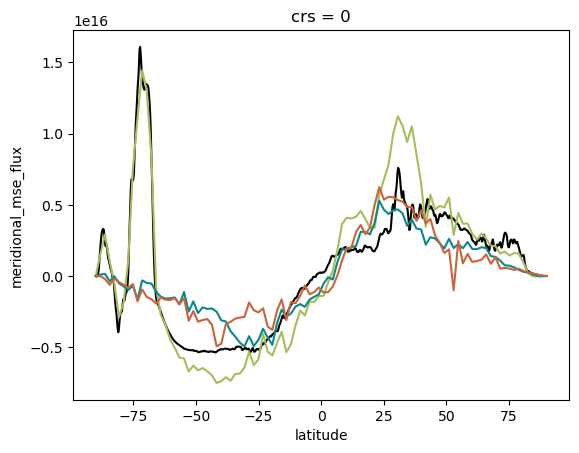

In [7]:
(xr.open_dataarray("monthly_era5_MEF.nc")*100).mean(dim="time").plot(
    label="ERA5", color="black"
)

for sim in sims_new:
    this_mef = xr.open_dataarray(f"monthly_{sim}_MEF_zoom_5.nc")
    if "icon" not in sim:
        this_mef*=100
    this_mef.mean(dim="time").plot(
        label=sim_labels[sim], color=sim_colors[sim]
    )
plt.legend()
plt.grid()
plt.title("DYAMOND3 period annual mean")
plt.xlim(-70,70)
plt.ylabel("Meridional column-integrated MSE flux")